In [1]:
# import dependencies
%matplotlib inline
import os
import sys
import spatioev as se
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Scimap
import scimap as sm

from spatioev.config import ClusteringConfig

Running SCIMAP  2.3.5


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
# set a working directory
wdir = ('/Users/shihongwu/SpatioEv')
os.chdir(wdir)

In [3]:
adata = se.load_h5ad("data/exp_2/34434_1_adata.h5ad")
adata

AnnData object with n_obs × n_vars = 1766481 × 37
    obs: 'label', 'area', 'eccentricity', 'major_axis_length', 'minor_axis_length', 'perimeter', 'convex_area', 'equivalent_diameter', 'orientation', 'solidity', 'feret_diameter_max', 'Y_centroid', 'X_centroid', 'major_minor_axis_ratio', 'perim_square_over_area', 'major_axis_equiv_diam_ratio', 'convex_hull_resid', 'centroid_dif', 'num_concavities', 'circularity', 'fractual_dimension', 'boundary_irregularity', 'nc_ratio', 'cell_size_nuclear', 'CD11b_nuclear', 'CD19_nuclear', 'CD20_nuclear', 'CD27_nuclear', 'CD3_nuclear', 'CD31_nuclear', 'CD38_nuclear', 'CD4_nuclear', 'CD4_2_nuclear', 'CD56_nuclear', 'CD8_nuclear', 'CD8_2_nuclear', 'CK19_nuclear', 'COL3_nuclear', 'CXCL13_nuclear', 'CXCR5_nuclear', 'DNA_1_nuclear', 'FAP_nuclear', 'FOXP3_nuclear', 'FOXP3_2_nuclear', 'GATA3_nuclear', 'GranzymeB_nuclear', 'HLADR_nuclear', 'IgA_nuclear', 'IgM_nuclear', 'Ki67_nuclear', 'MERTK_nuclear', 'NaKATPase_nuclear', 'PCK_nuclear', 'PDGFRa_nuclear', 'PDL1

In [4]:
# 1) Read annotations CSV (saved from adata_final.obs.to_csv, so index is first column)
ann = pd.read_csv("data/exp_2/34434_1_annotation.csv", index_col=0)

# 2) Optional: keep only columns you want
ann = ann[["Tier_A", "Tier_B"]]

# 3) Join into adata.obs by cell ID (index)
adata.obs = adata.obs.join(ann, how="left")

In [5]:
adata.obs["Tier_A"].value_counts()

Tier_A
Fibroblasts                     447488
pancreatic ductal epithelium    423758
Vimentin only mesenchyme        285392
Endothelial cells               137447
pancreatic acinar epithelium    124722
T cells                         106306
Muscularis externa               64475
B lineage                        60907
Vascular smooth muscle           45169
Duodenum epithelial              19284
noise                            18725
Nerves                            9980
Islets                            9202
Necrotic tumor                    7826
Muscularis mucosa                 5749
Unknown                             51
Name: count, dtype: int64

In [6]:
# read in pixel features
pix = pd.read_csv("data/exp_2/pixel_features.csv", index_col=0)
pix.head()

# join pixel features into adata.obs by label and fov
adata.obs = adata.obs.merge(pix, 
                            on=["label", "fov"],
                            how="left")

In [7]:
# Remove cells with NaN in pixel feature columns
pix_cols = pix.columns.tolist()
mask = adata.obs[pix_cols].notna().all(axis=1)
print(f"Keeping {mask.sum()} / {len(mask)} cells after removing NaN rows")
adata = adata[mask].copy()

Keeping 1763634 / 1766481 cells after removing NaN rows


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



In [8]:
adata = se.cluster_spatial_components_from_mask(
    adata,
    seg_dir="data/exp_2/segmentation",
    label_key="Tier_A",
    label_value="pancreatic ductal epithelium",
    fov_key="fov",
    cell_label_key="label",
    connection_mode="label_adjacency",
    gap_tolerance=5,
    stitch_across_fovs=True,
    fov_grid_cols=2,
    stitch_gap_tolerance=5,
    connectivity=2,
    min_component_size=3,
    assign_singletons=True,
)

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'pancreatic ductal epithelium_mask_component'}, xlabel='X_centroid', ylabel='Y_centroid'>)

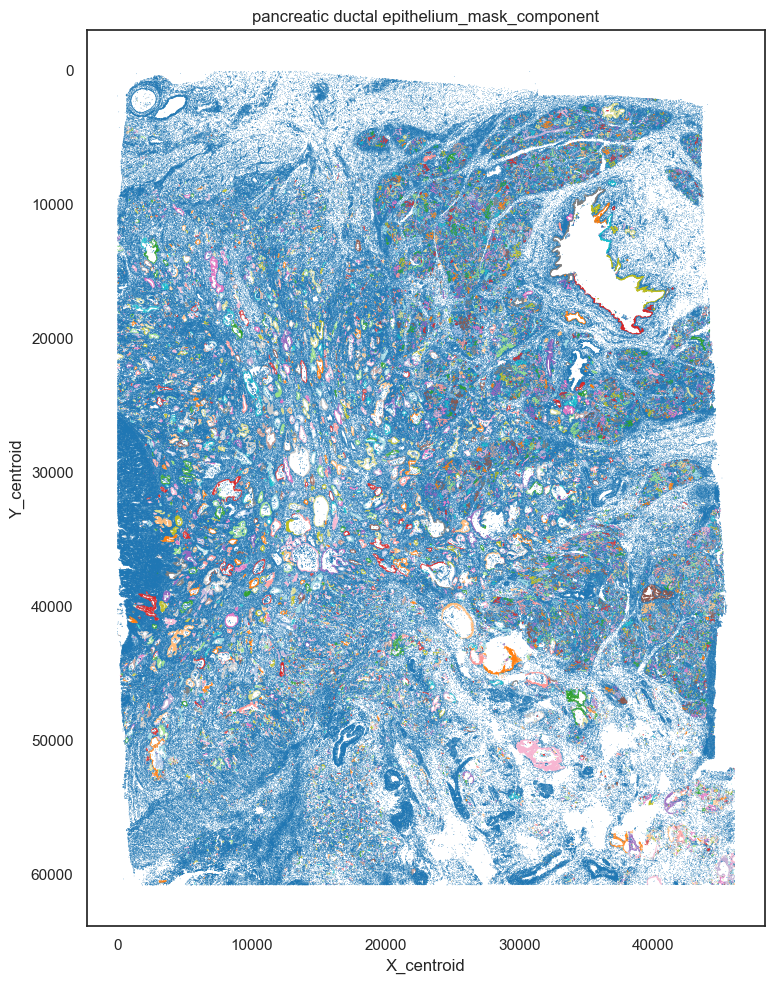

In [9]:
se.plot_spatial_category(
    adata,
    feature="pancreatic ductal epithelium_mask_component",
    image_id=None,          # or one image id like "exp"
    image_key="imageid",
    x_key="X_centroid",
    y_key="Y_centroid",
    point_size=0.2,
    alpha=1,
    palette="tab20",
    show_legend=False,      # important for long component lists
    figsize=(10, 10),
)

### cell graph

In [10]:
from scipy import sparse
import pandas as pd

marker_candidates = ["FAP", "aSMA", "PDPN", "Thy1", "Ki67", "CK19", "NaKATPase", "Vimentin"]
markers_present = [m for m in marker_candidates if m in adata.var_names]
if markers_present:
    adata = se.add_obs_from_var(
        adata,
        markers=markers_present,
        zscore=True,
        overwrite=True,
    )

obs_feature_candidates = [
    "nc_ratio",
    "polarity_score",
    "entropy",
    "inertia",
    "boundary_irregularity",
    "major_minor_axis_ratio",
    "centroid_dif",
    "num_concavities",
    "lacunarity",
    "haralick_contrast",
    "haralick_correlation",
    "haralick_energy",
    "haralick_homogeneity",
    "pcc_ck19_nak",
    "intensity_ratio",
    "solidity",
    "perimeter",
    "convex_hull_resid",
]
obs_features_present = [f for f in obs_feature_candidates if f in adata.obs.columns]
if obs_features_present:
    adata = se.add_zscore_obs_features(
        adata,
        feature_keys=obs_features_present,
        overwrite=True,
    )


In [11]:
adata = se.build_cell_graph(
    adata,
    feature_cols=[# cell features
                  "area", 'eccentricity', 'major_axis_length', 'minor_axis_length', 'perimeter', 
                  'convex_area', 'equivalent_diameter', 'orientation', 'solidity', 'feret_diameter_max',
                  'major_minor_axis_ratio', 'perim_square_over_area', 'major_axis_equiv_diam_ratio', 
                  'convex_hull_resid', 'centroid_dif', 'num_concavities', 'circularity', 
                  'fractual_dimension', 'boundary_irregularity', 'nc_ratio', 
                  # pixel features
                  'polarity_score', 'haralick_contrast', 'haralick_correlation', 'haralick_energy', 
                  'haralick_homogeneity', 'entropy', 'pcc_ck19_nak', 'intensity_ratio', 'inertia', 
                  'lacunarity',
                  "CK19_expr", "Vimentin_expr", "NaKATPase_expr",],
    phenotype_key="Tier_A",
    radius=30/0.325, # 30 microns converted to pixels
    image_key="imageid",
    auto_log =True,
    compute_weights=True,
    sigma_space=None,
    sigma_feat=None,
    feature_obsm_key="cell_features",
    adjacency_key="cell_graph_connectivities",
    distance_key="cell_graph_distances",
    graph_obs_key="cell_graph_valid",
)


### build niche graphs

In [ ]:
niche_feature_df = se.build_niche_feature_table_batched(
    adata,
    niche_key="pancreatic ductal epithelium_mask_component",
    batch_size=10,
    include_prefix="global__component",
    exclude_values=("unassigned", "noise"),
    exclude_prefixes=("global__singleton_",),
    feature_cols=[
        "area", "major_minor_axis_ratio", "orientation", "centroid_dif", "nc_ratio",
        "boundary_irregularity", "solidity", "convex_hull_resid",
        "polarity_score", "haralick_contrast", "haralick_correlation", "haralick_energy",
        "haralick_homogeneity", "entropy", "pcc_ck19_nak", "intensity_ratio", "inertia",
        "lacunarity", "CK19_expr", "NaKATPase_expr", "Ki67_expr"
    ],
    state_feature_cols=[
        "area", "eccentricity", "major_axis_length", "minor_axis_length", "perimeter",
        "convex_area", "equivalent_diameter", "orientation", "solidity", "feret_diameter_max",
        "major_minor_axis_ratio", "perim_square_over_area", "major_axis_equiv_diam_ratio",
        "convex_hull_resid", "centroid_dif", "num_concavities", "circularity",
        "fractual_dimension", "boundary_irregularity", "nc_ratio",
        
        "polarity_score", "haralick_contrast", "haralick_correlation", "haralick_energy",
        "haralick_homogeneity", "entropy", "pcc_ck19_nak", "intensity_ratio", 
        "inertia",  "lacunarity", 
        "CK19_expr", "Vimentin_expr", "NaKATPase_expr", "Ki67_expr", 
    ],
    phenotype_key="Tier_A",
    min_cells=5,
    include_graph_surroundings=True,
    surround_hops=5,
    include_state_summaries=True,
    state_summary_stats=("mean", "median", "std", "iqr", "p10", "p90"),
    lightweight=False,
    show_progress=True,
    progress_desc="Batches",
    show_progress_inner=True,
    progress_desc_inner="Niches in batch",
)

Batches:  32%|███▏      | 520/1627 [12:52<23:32,  1.28s/it]/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/networkx/algorithms/assortativity/correlation.py:302: RuntimeWarning:

invalid value encountered in scalar divide

Batches: 100%|██████████| 1627/1627 [38:16<00:00,  1.41s/it]


In [14]:
niche_feature_df.to_csv("data/exp_2/niche_feature_table.csv")

In [12]:
niche_feature_df = pd.read_csv("data/exp_2/niche_feature_table.csv", index_col=0)
niche_feature_df.head()

,pancreatic ductal epithelium_mask_component,image_id,n_cells,topology__n_nodes,topology__n_edges,topology__density,topology__avg_degree,topology__degree_var,topology__degree_cv,topology__leaf_fraction,...,state__NaKATPase_expr__p90,state__Ki67_expr__mean,state__Ki67_expr__median,state__Ki67_expr__std,state__Ki67_expr__iqr,state__Ki67_expr__p10,state__Ki67_expr__p90,state__phenotype_entropy,state__phenotype_dominant_fraction,state__phenotype__pancreatic_ductal_epithelium__proportion
0,global__component_0,34434_1,8.0,8.0,19.0,0.678571,4.750000,1.937500,0.293040,0.0,...,13.615536,11.804684,11.799242,0.420649,0.538810,11.303032,12.300434,0.0,1.0,1.0
1,global__component_1,34434_1,104.0,104.0,1373.0,0.256348,26.403846,66.452293,0.308736,0.0,...,14.616897,11.208009,11.210027,0.151260,0.165741,11.001950,11.411742,0.0,1.0,1.0
2,global__component_2,34434_1,6.0,6.0,13.0,0.866667,4.333333,0.555556,0.172005,0.0,...,14.044411,11.940049,11.880253,0.317973,0.322176,11.615782,12.324112,0.0,1.0,1.0
3,global__component_3,34434_1,65.0,65.0,730.0,0.350962,22.461538,36.617751,0.269405,0.0,...,14.780220,11.232875,11.215255,0.273521,0.183962,10.993568,11.393604,0.0,1.0,1.0
4,global__component_4,34434_1,10.0,10.0,30.0,0.666667,6.000000,2.600000,0.268742,0.0,...,14.106002,11.409850,11.184746,0.570317,0.455219,10.980649,12.168660,0.0,1.0,1.0


## PDAC Pathology-Module Branching Pseudotime

This section keeps the graph/niche workflow but replaces the flat weighted feature table with pathology-inspired PDAC modules. The principal tree is still branching; the main change is that the input space is now organized around gland organization, dysplasia/complexity, invasion-desmoplasia, and dedifferentiation.

In [13]:
niche_key = "pancreatic ductal epithelium_mask_component"
fibro_context_features = [
    col for col in ["FAP_expr_z", "aSMA_expr_z", "PDPN_expr_z", "Thy1_expr_z"]
    if col in adata.obs.columns
]
phenotype_labels = (
    adata.obs["Tier_A"]
    .value_counts()
    .loc[lambda s: ~s.index.isin(["noise", "Unknown"])]
    .index.tolist()
)

surround_context_df = se.summarize_niche_surrounding_context(
    adata,
    niche_key=niche_key,
    phenotype_key="Tier_A",
    phenotype_labels=phenotype_labels,
    phenotype_feature_map={"Fibroblasts": fibro_context_features},
    surround_hops=5,
)

context_cols = [col for col in surround_context_df.columns if col != "n_cells"]
pathology_feature_df = niche_feature_df.merge(
    surround_context_df[context_cols],
    on=[niche_key, "image_id"],
    how="left",
)

pathology_module_df = se.score_pdac_niche_pathology_modules(
    pathology_feature_df,
    niche_key=niche_key,
    polarity_high_is_organized=True,
)

pathology_feature_df = pathology_feature_df.merge(
    pathology_module_df,
    on=[niche_key, "image_id"],
    how="left",
)

pathology_feature_df.head()

,pancreatic ductal epithelium_mask_component,image_id,n_cells,topology__n_nodes,topology__n_edges,topology__density,topology__avg_degree,topology__degree_var,topology__degree_cv,topology__leaf_fraction,...,pdac_panin_like_dysplasia_score__n_features,pdac_panin_like_dysplasia_score,pdac_invasive_gland_forming_score__n_features,pdac_invasive_gland_forming_score,pdac_invasion_desmoplasia_axis__n_features,pdac_invasion_desmoplasia_axis,pdac_proliferation_axis__n_features,pdac_proliferation_axis,pdac_dedifferentiation_axis__n_features,pdac_dedifferentiation_axis
0,global__component_0,34434_1,8.0,8.0,19.0,0.678571,4.750000,1.937500,0.293040,0.0,...,3.0,-0.826417,4.0,0.815581,1.0,-0.641489,1.0,2.157928,2.0,-0.872942
1,global__component_1,34434_1,104.0,104.0,1373.0,0.256348,26.403846,66.452293,0.308736,0.0,...,3.0,0.088740,4.0,-0.314186,1.0,0.195338,1.0,0.425696,2.0,0.938889
2,global__component_2,34434_1,6.0,6.0,13.0,0.866667,4.333333,0.555556,0.172005,0.0,...,3.0,1.186396,4.0,0.256356,1.0,0.817112,1.0,2.376697,2.0,1.084192
3,global__component_3,34434_1,65.0,65.0,730.0,0.350962,22.461538,36.617751,0.269405,0.0,...,3.0,-0.207391,4.0,0.223649,1.0,0.287697,1.0,0.443866,2.0,-0.081516
4,global__component_4,34434_1,10.0,10.0,30.0,0.666667,6.000000,2.600000,0.268742,0.0,...,3.0,-0.498788,4.0,0.468006,1.0,-0.496942,1.0,1.458422,2.0,-0.455271


In [14]:
resolved_rows = []
for module_name, items in pathology_module_df.attrs.get("resolved_module_features", {}).items():
    for col, sign in items:
        resolved_rows.append({
            "module": module_name,
            "feature": col,
            "sign": sign,
        })

resolved_module_features_df = pd.DataFrame(resolved_rows)
resolved_module_features_df

,module,feature,sign
0,pdac_duct_organization_score,geometry__hull_circularity,1.0
1,pdac_duct_organization_score,topology__largest_component_fraction,1.0
2,pdac_duct_organization_score,geometry__mean_nearest_neighbor_distance,1.0
3,pdac_duct_organization_score,state__CK19_expr__mean,1.0
4,pdac_duct_organization_score,state__NaKATPase_expr__mean,1.0
5,pdac_duct_organization_score,state__polarity_score__median,1.0
6,pdac_duct_organization_score,graph_boundary__boundary_fraction,-1.0
7,pdac_duct_organization_score,graph_boundary__mean_external_degree,-1.0
8,pdac_duct_organization_score,topology__bridge_fraction,-1.0
9,pdac_duct_organization_score,topology__skeleton_branchpoint_fraction,-1.0


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



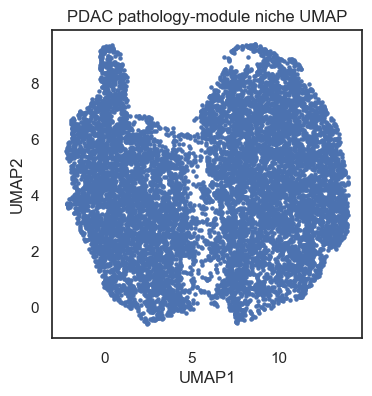

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from umap import UMAP

module_cols = [
    "pdac_early_duct_anchor_score",
    "pdac_panin_like_dysplasia_score",
    "pdac_invasive_gland_forming_score",
    "pdac_invasion_desmoplasia_axis",
    "pdac_proliferation_axis",
    "pdac_dedifferentiation_axis",
    "pdac_duct_organization_score",
    "pdac_dysplasia_score",
    "pdac_architectural_complexity_score",
    "pdac_invasion_desmoplasia_score",
    "pdac_proliferation_score",
    "pdac_dedifferentiation_score",
]

supplemental_cols = [
    col for col in [
        "geometry__hull_circularity",
        "geometry__mean_nearest_neighbor_distance",
        "graph_boundary__boundary_fraction",
        "graph_boundary__mean_external_degree",
        "graph_surround__cross_edges_per_niche_cell",
        "topology__skeleton_tortuosity",
        "surround_prop__Fibroblasts",
        "surround_prop__Vimentin_only_mesenchyme",
        "surround_prop__Endothelial_cells",
    ]
    if col in pathology_feature_df.columns
]

size_qc_cols = [
    col for col in [
        "n_cells",
        "geometry__convex_hull_area",
        "geometry__convex_hull_perimeter",
    ]
    if col in pathology_feature_df.columns
]

gland_proxy_cols = [
    col for col in [
        "state__solidity__mean",
        "state__solidity__std",
        "state__perimeter__mean",
        "state__perimeter__std",
        "state__convex_hull_resid__mean",
        "state__convex_hull_resid__std",
    ]
    if col in pathology_feature_df.columns
]

extra_pixel_cols = [
    col for col in [
        "state__nc_ratio__std",
        "state__nc_ratio__iqr",
        "state__polarity_score__std",
        "state__entropy__std",
        "state__inertia__std",
        "state__lacunarity__std",
        "state__haralick_contrast__std",
        "state__haralick_correlation__mean",
        "state__haralick_energy__mean",
        "state__haralick_homogeneity__mean",
        "state__pcc_ck19_nak__mean",
        "state__pcc_ck19_nak__std",
        "state__intensity_ratio__mean",
        "state__intensity_ratio__std",
        "graph_boundary__polarity_score__boundary_minus_core",
        "graph_boundary__entropy__boundary_minus_core",
        "graph_boundary__haralick_contrast__boundary_minus_core",
        "graph_boundary__intensity_ratio__boundary_minus_core",
        "graph_boundary__pcc_ck19_nak__boundary_minus_core",
    ]
    if col in pathology_feature_df.columns
]

meta_cols = [niche_key, "image_id", "n_cells"]
meta_path = pathology_feature_df[[c for c in meta_cols if c in pathology_feature_df.columns]].copy()

path_feature_cols = list(dict.fromkeys(module_cols + supplemental_cols + gland_proxy_cols + extra_pixel_cols))
X_path = pathology_feature_df[path_feature_cols].apply(pd.to_numeric, errors="coerce")
na_frac = X_path.isna().mean()
X_path = X_path.loc[:, na_frac < 0.3]
X_path = X_path.apply(lambda col: col.fillna(col.median()), axis=0)
X_path = X_path.loc[:, X_path.var() > 1e-8]

priority_cols = [col for col in module_cols if col in X_path.columns]
candidate_cols = [col for col in X_path.columns if col not in priority_cols]
corr_abs = X_path.corr().abs()
selected_cols = list(priority_cols)
for col in candidate_cols:
    if len(selected_cols) == 0:
        selected_cols.append(col)
        continue
    col_corr = corr_abs.loc[col, selected_cols].dropna()
    max_corr = col_corr.max() if len(col_corr) > 0 else np.nan
    if (not np.isfinite(max_corr)) or (max_corr < 0.95):
        selected_cols.append(col)
X_path = X_path[selected_cols]

scaler = StandardScaler()
X_path_scaled = scaler.fit_transform(X_path)

pca = PCA(n_components=min(10, X_path.shape[1]))
X_path_pca = pca.fit_transform(X_path_scaled)
n_pcs_path = min(5, X_path_pca.shape[1])
X_path_pca_use = X_path_pca[:, :n_pcs_path]

umap_model = UMAP(
    n_neighbors=10,
    min_dist=0.2,
    n_components=2,
    random_state=42,
)
X_path_umap = umap_model.fit_transform(X_path_pca_use)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(X_path_umap[:, 0], X_path_umap[:, 1], s=5)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("PDAC pathology-module niche UMAP")
ax.grid(False)
plt.show()

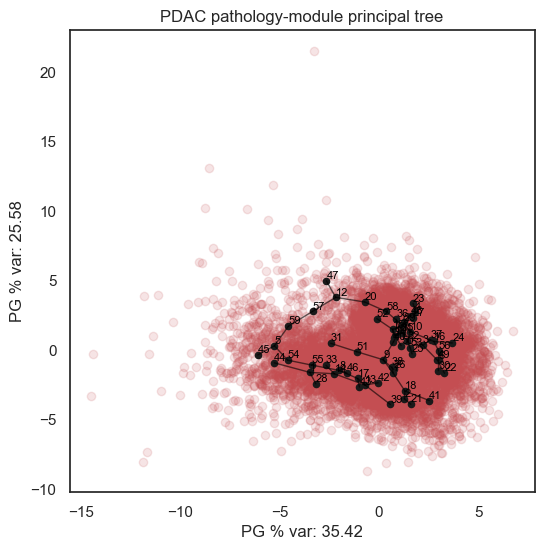

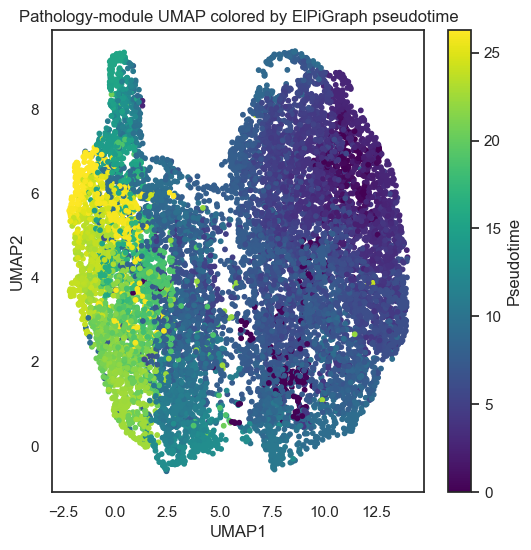

In [16]:
import elpigraph

reduced_data = X_path_pca_use
pg_tree_path = elpigraph.computeElasticPrincipalTree(
    X=reduced_data,
    NumNodes=60,
    Lambda=0.005,
    Mu=0.01,
)[0]

early_anchor_score = pd.to_numeric(pathology_feature_df["pdac_early_duct_anchor_score"], errors="coerce")
root_mask = early_anchor_score >= early_anchor_score.quantile(0.9)
if root_mask.fillna(False).sum() == 0:
    root_mask = early_anchor_score == early_anchor_score.max()
root_anchor = reduced_data[root_mask.to_numpy()].mean(axis=0)
source_node_path = int(np.argmin(np.sum((pg_tree_path["NodePositions"] - root_anchor) ** 2, axis=1)))

elpigraph.utils.getPseudotime(
    X=reduced_data,
    PG=pg_tree_path,
    source=source_node_path,
    target=None,
)

pseudotime_path = pg_tree_path["pseudotime"]
proj_path = pg_tree_path["projection"]

niche_result_pathology = meta_path.copy()
niche_result_pathology["elpigraph_pseudotime"] = pseudotime_path
niche_result_pathology["elpigraph_node_id"] = proj_path["node_id"]
niche_result_pathology["elpigraph_edge_id"] = proj_path["edge_id"]
niche_result_pathology["UMAP1"] = X_path_umap[:, 0]
niche_result_pathology["UMAP2"] = X_path_umap[:, 1]

niche_result = niche_result_pathology.copy()

plt.figure(figsize=(6, 6))
plt.rcParams.update({"font.size": 8})
elpigraph.plot.PlotPG(
    reduced_data,
    pg_tree_path,
    Do_PCA=True,
    show_text=True,
)
plt.title("PDAC pathology-module principal tree")
plt.grid(False)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(
    X_path_umap[:, 0],
    X_path_umap[:, 1],
    c=niche_result_pathology["elpigraph_pseudotime"],
    cmap="viridis",
    s=10,
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Pathology-module UMAP colored by ElPiGraph pseudotime")
plt.colorbar(label="Pseudotime")
plt.grid(False)
plt.show()


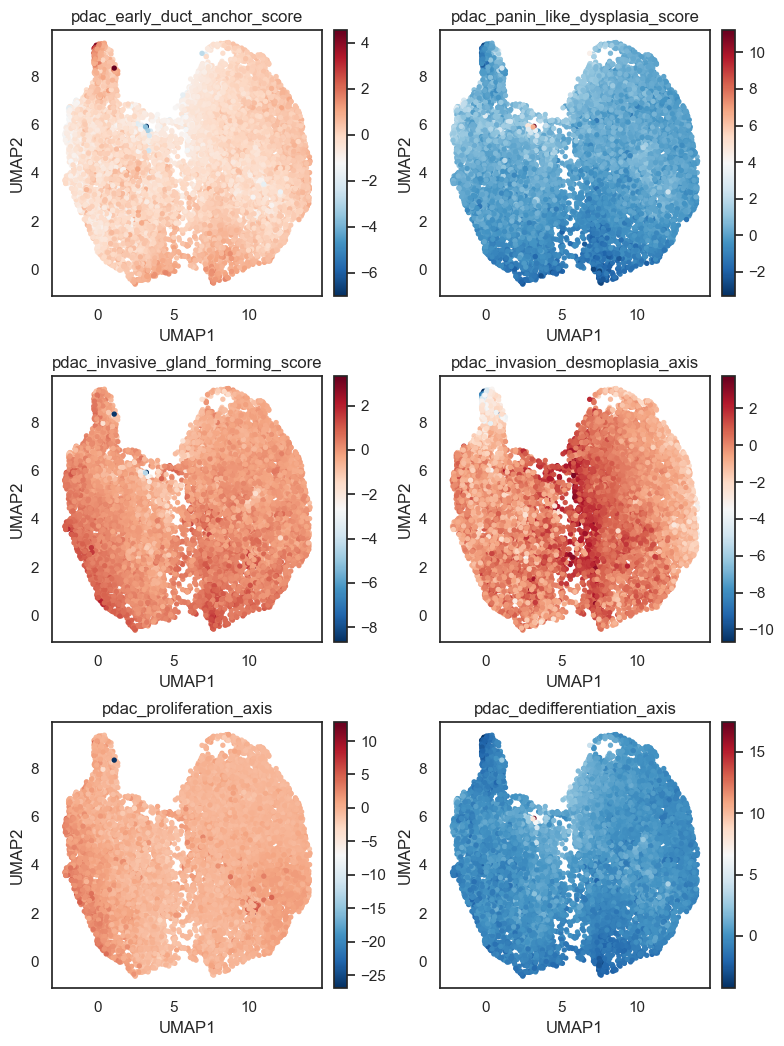

,pancreatic ductal epithelium_mask_component,image_id,n_cells,n_surround,surround__hop_1__n_cells,surround__hop_2__n_cells,surround__hop_3__n_cells,surround__hop_4__n_cells,surround__hop_5__n_cells,surround_prop__Fibroblasts,...,surround__Fibroblasts__aSMA_expr_z__mean,surround__Fibroblasts__aSMA_expr_z__median,surround__Fibroblasts__PDPN_expr_z__n_cells,surround__Fibroblasts__PDPN_expr_z__mean,surround__Fibroblasts__PDPN_expr_z__median,surround__Fibroblasts__Thy1_expr_z__n_cells,surround__Fibroblasts__Thy1_expr_z__mean,surround__Fibroblasts__Thy1_expr_z__median,elpigraph_pseudotime,elpigraph_edge_id
0,global__component_0,34434_1,8.0,169.0,23.0,31.0,30.0,33.0,52.0,0.272189,...,0.527217,0.421768,46.0,-0.957828,-0.761341,46.0,0.647440,0.597582,22.569000,29.0
1,global__component_1,34434_1,104.0,1088.0,171.0,197.0,227.0,247.0,246.0,0.155331,...,1.039885,0.965036,169.0,-0.564180,-0.556530,169.0,0.039228,-0.043310,4.659995,40.0
2,global__component_10,34434_1,25.0,926.0,106.0,129.0,178.0,230.0,283.0,0.153348,...,1.060070,1.051203,142.0,-0.543227,-0.526444,142.0,-0.015356,-0.123913,5.238981,22.0
3,global__component_100,34434_1,28.0,914.0,86.0,142.0,194.0,233.0,259.0,0.079869,...,0.689166,0.754862,73.0,-0.234806,-0.204886,73.0,0.524342,0.431018,5.617821,13.0
4,global__component_1000,34434_1,10.0,827.0,39.0,95.0,160.0,246.0,287.0,0.016929,...,0.497966,0.678865,14.0,-0.572896,-0.628425,14.0,0.006619,0.024318,4.204156,43.0


In [17]:
module_plot_cols = [
    "pdac_early_duct_anchor_score",
    "pdac_panin_like_dysplasia_score",
    "pdac_invasive_gland_forming_score",
    "pdac_invasion_desmoplasia_axis",
    "pdac_proliferation_axis",
    "pdac_dedifferentiation_axis",
]

n_cols = 2
n_rows = (len(module_plot_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, module_plot_cols):
    sc = ax.scatter(
        X_path_umap[:, 0],
        X_path_umap[:, 1],
        c=pathology_feature_df[col],
        cmap="RdBu_r",
        s=8,
    )
    ax.set_title(col)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.grid(False)
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

for ax in axes[len(module_plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

surround_summary_df = surround_context_df.merge(
    niche_result_pathology[[niche_key, "image_id", "elpigraph_pseudotime", "elpigraph_edge_id"]],
    on=[niche_key, "image_id"],
    how="left",
)
surround_summary_df.head()


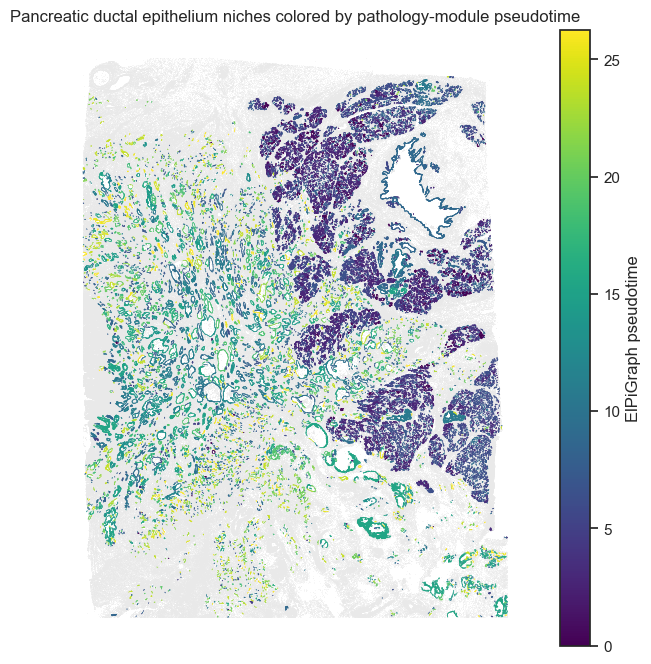

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

niche_key = "pancreatic ductal epithelium_mask_component"

# map niche-level trajectory results back to cells using both niche id and image id
niche_lookup = niche_result_pathology.set_index([niche_key, "image_id"])[
    ["elpigraph_pseudotime", "elpigraph_node_id", "elpigraph_edge_id"]
]
cell_lookup_index = pd.MultiIndex.from_frame(
    adata.obs[[niche_key, "imageid"]].rename(columns={"imageid": "image_id"})
)
cell_lookup = niche_lookup.reindex(cell_lookup_index)

adata.obs["elpigraph_pseudotime_pathology"] = cell_lookup["elpigraph_pseudotime"].to_numpy()
adata.obs["elpigraph_node_id_pathology"] = cell_lookup["elpigraph_node_id"].to_numpy()
adata.obs["elpigraph_edge_id_pathology"] = cell_lookup["elpigraph_edge_id"].to_numpy()

na_mask = adata.obs["elpigraph_pseudotime_pathology"].isna()

fig, ax = plt.subplots(figsize=(8, 8))

# background cells in gray
sns.scatterplot(
    data=adata.obs[na_mask],
    x="X_centroid",
    y="Y_centroid",
    color="lightgray",
    s=0.25,
    alpha=0.5,
    linewidth=0,
    ax=ax,
)

# niche-assigned cells colored by pathology pseudotime
sc = ax.scatter(
    adata.obs.loc[~na_mask, "X_centroid"],
    adata.obs.loc[~na_mask, "Y_centroid"],
    c=adata.obs.loc[~na_mask, "elpigraph_pseudotime_pathology"],
    cmap="viridis",
    s=0.2,
    alpha=1,
    linewidths=0,
)

ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("ElPiGraph pseudotime")

plt.title("Pancreatic ductal epithelium niches colored by pathology-module pseudotime")
plt.show()

/var/folders/kg/btvhyzjs5fb7f_57bfqf24tr0000gn/T/ipykernel_63891/1194714185.py:29: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



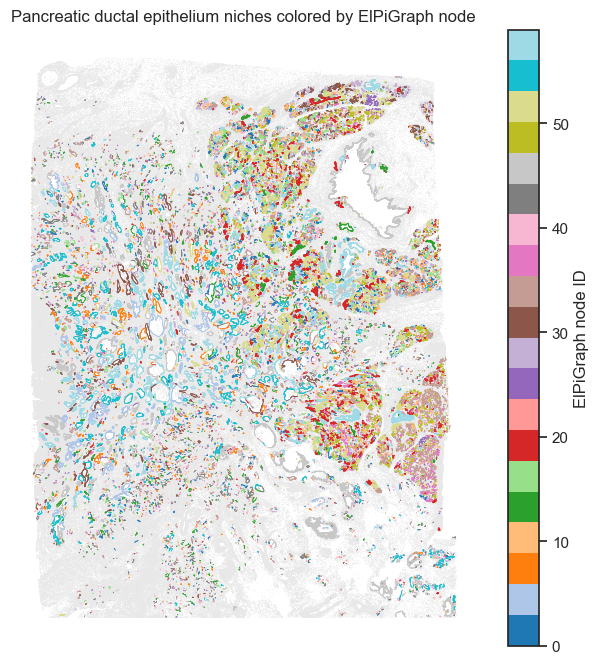

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

niche_key = "pancreatic ductal epithelium_mask_component"

node_mask = adata.obs["elpigraph_node_id_pathology"].notna()

fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    data=adata.obs[~node_mask],
    x="X_centroid",
    y="Y_centroid",
    color="lightgray",
    s=0.25,
    alpha=0.4,
    linewidth=0,
    ax=ax,
)

node_vals = adata.obs.loc[node_mask, "elpigraph_node_id_pathology"].astype(int)
n_nodes = node_vals.nunique()

sc = ax.scatter(
    adata.obs.loc[node_mask, "X_centroid"],
    adata.obs.loc[node_mask, "Y_centroid"],
    c=node_vals,
    cmap=plt.cm.get_cmap("tab20", max(n_nodes, 2)),
    s=0.25,
    alpha=1,
    linewidths=0,
)

ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("ElPiGraph node ID")

plt.title("Pancreatic ductal epithelium niches colored by ElPiGraph node")
plt.show()


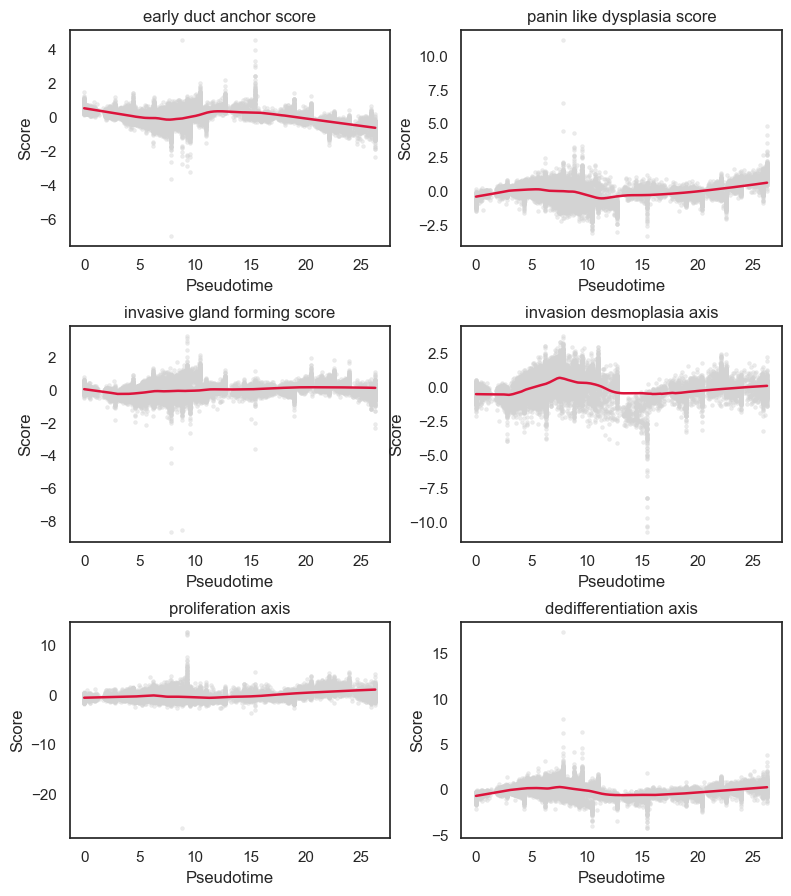

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as ssm
import numpy as np

plot_df = pathology_feature_df.merge(
    niche_result_pathology[[niche_key, "image_id", "elpigraph_pseudotime"]],
    on=[niche_key, "image_id"],
    how="left",
)

module_cols = [
    "pdac_early_duct_anchor_score",
    "pdac_panin_like_dysplasia_score",
    "pdac_invasive_gland_forming_score",
    "pdac_invasion_desmoplasia_axis",
    "pdac_proliferation_axis",
    "pdac_dedifferentiation_axis",
]

n_cols = 2
n_rows = (len(module_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 3.0 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, module_cols):
    tmp = plot_df[["elpigraph_pseudotime", col]].dropna().copy()
    tmp = tmp.sort_values("elpigraph_pseudotime")

    sns.scatterplot(
        data=tmp,
        x="elpigraph_pseudotime",
        y=col,
        s=8,
        color="lightgray",
        edgecolor=None,
        alpha=0.45,
        legend=False,
        ax=ax,
    )

    if len(tmp) >= 15:
        lowess = ssm.nonparametric.lowess(
            tmp[col],
            tmp["elpigraph_pseudotime"],
            frac=0.3,
            return_sorted=True,
        )
        ax.plot(lowess[:, 0], lowess[:, 1], color="crimson", linewidth=1.8)

    ax.set_title(col.replace("pdac_", "").replace("_", " "))
    ax.set_xlabel("Pseudotime")
    ax.set_ylabel("Score")
    ax.grid(False)

for ax in axes[len(module_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning:

invalid value encountered in divide

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning:

invalid value encountered in divide

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning:

invalid value encountered in divide

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning:

invalid value encountered in divide

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning:

invalid value encountered in divide

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/statsmodels/nonparametric/smoot

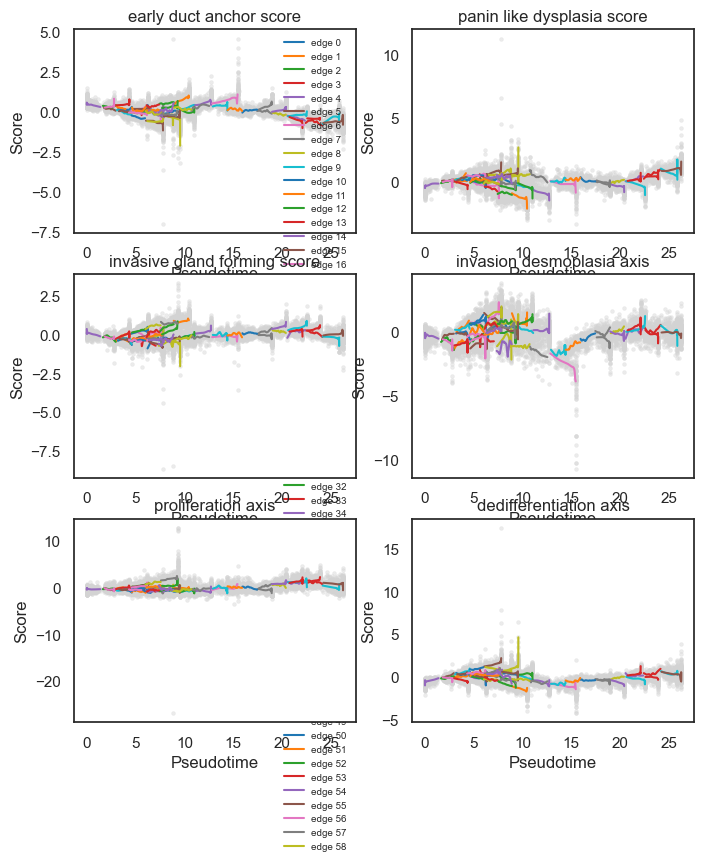

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as ssm

plot_df = pathology_feature_df.merge(
    niche_result_pathology[[niche_key, "image_id", "elpigraph_pseudotime", "elpigraph_edge_id"]],
    on=[niche_key, "image_id"],
    how="left",
)

module_cols = [
    "pdac_early_duct_anchor_score",
    "pdac_panin_like_dysplasia_score",
    "pdac_invasive_gland_forming_score",
    "pdac_invasion_desmoplasia_axis",
    "pdac_proliferation_axis",
    "pdac_dedifferentiation_axis",
]
edge_palette = sns.color_palette("tab10", n_colors=max(plot_df["elpigraph_edge_id"].nunique(dropna=True), 1))

n_cols = 2
n_rows = (len(module_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 3.0 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, module_cols):
    tmp = plot_df[["elpigraph_pseudotime", "elpigraph_edge_id", col]].dropna().copy()
    tmp = tmp.sort_values("elpigraph_pseudotime")

    sns.scatterplot(
        data=tmp,
        x="elpigraph_pseudotime",
        y=col,
        s=8,
        color="lightgray",
        edgecolor=None,
        alpha=0.45,
        legend=False,
        ax=ax,
    )

    for color, (edge_id, df_edge) in zip(edge_palette, tmp.groupby("elpigraph_edge_id", dropna=True)):
        df_edge = df_edge.sort_values("elpigraph_pseudotime")
        if len(df_edge) < 15:
            continue
        lowess = ssm.nonparametric.lowess(
            df_edge[col],
            df_edge["elpigraph_pseudotime"],
            frac=0.3,
            return_sorted=True,
        )
        ax.plot(lowess[:, 0], lowess[:, 1], color=color, linewidth=1.5, label=f"edge {edge_id}")

    ax.set_title(col.replace("pdac_", "").replace("_", " "))
    ax.set_xlabel("Pseudotime")
    ax.set_ylabel("Score")
    ax.grid(False)

for ax in axes[len(module_cols):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend(frameon=False, fontsize=7, loc="best")

plt.tight_layout()
plt.show()

In [22]:
# Cell 1: marker prep + surround summaries + edge summary

marker_candidates = [
    "FAP", "aSMA", "PDPN", "Thy1", "Vimentin",
    "CK19", "NaKATPase", "Ki67",
    "CD31", "CD3", "CD4_2", "CD8_2", "FOXP3_2", "GranzymeB",
    "CD19", "CD20", "CD27", "CD38", "IgA", "IgM", "PDL1",
]

markers_present = [m for m in marker_candidates if m in adata.var_names]
print("Markers found in adata.var_names:")
print(markers_present)

adata = se.add_obs_from_var(
    adata,
    markers=markers_present,
    zscore=True,
    overwrite=True,
)

niche_key = "pancreatic ductal epithelium_mask_component"

phenotype_labels = (
    adata.obs["Tier_A"]
    .value_counts()
    .loc[lambda s: ~s.index.isin(["noise", "Unknown"])]
    .index.tolist()
)

phenotype_feature_map_candidates = {
    "Fibroblasts": ["FAP_expr", "aSMA_expr", "PDPN_expr", "Thy1_expr", "Vimentin_expr"],
    "pancreatic ductal epithelium": ["CK19_expr", "NaKATPase_expr", "Ki67_expr", "Vimentin_expr"],
    "Endothelial cells": ["CD31_expr", "PDPN_expr"],
    "T cells": ["CD3_expr", "CD4_2_expr", "CD8_2_expr", "FOXP3_2_expr", "GranzymeB_expr", "Ki67_expr"],
    "B lineage": ["CD19_expr", "CD20_expr", "CD27_expr", "CD38_expr", "IgA_expr", "IgM_expr", "PDL1_expr"],
    "Vimentin only mesenchyme": ["Vimentin_expr"],
    "pancreatic acinar epithelium": ["CK19_expr", "NaKATPase_expr", "Vimentin_expr"],
}

phenotype_feature_map = {
    label: [col for col in cols if col in adata.obs.columns]
    for label, cols in phenotype_feature_map_candidates.items()
}
phenotype_feature_map = {
    label: cols
    for label, cols in phenotype_feature_map.items()
    if len(cols) > 0
}

print("\nPhenotype feature map used:")
for label, cols in phenotype_feature_map.items():
    print(f"{label}: {cols}")

surround_context_df = se.summarize_niche_surrounding_context(
    adata,
    niche_key=niche_key,
    phenotype_key="Tier_A",
    phenotype_labels=phenotype_labels,
    phenotype_feature_map=phenotype_feature_map,
    surround_hops=5,
)

context_cols = [col for col in surround_context_df.columns if col != "n_cells"]
pathology_feature_df = niche_feature_df.merge(
    surround_context_df[context_cols],
    on=[niche_key, "image_id"],
    how="left",
)

pathology_module_df = se.score_pdac_niche_pathology_modules(
    pathology_feature_df,
    niche_key=niche_key,
    polarity_high_is_organized=True,
)

pathology_feature_df = pathology_feature_df.merge(
    pathology_module_df,
    on=[niche_key, "image_id"],
    how="left",
)

plot_df = pathology_feature_df.merge(
    niche_result_pathology[[niche_key, "image_id", "elpigraph_pseudotime", "elpigraph_edge_id"]],
    on=[niche_key, "image_id"],
    how="left",
)

surround_plot_df = surround_context_df.merge(
    niche_result_pathology[[niche_key, "image_id", "elpigraph_pseudotime", "elpigraph_edge_id"]],
    on=[niche_key, "image_id"],
    how="left",
)

edge_summary_df = (
    plot_df.groupby("elpigraph_edge_id", dropna=True)
    .agg(
        n_niches=(niche_key, "nunique"),
        pseudotime_min=("elpigraph_pseudotime", "min"),
        pseudotime_max=("elpigraph_pseudotime", "max"),
        early_anchor_mean=("pdac_early_duct_anchor_score", "mean"),
        invasion_mean=("pdac_invasion_desmoplasia_axis", "mean"),
        proliferation_mean=("pdac_proliferation_axis", "mean"),
        dedifferentiation_mean=("pdac_dedifferentiation_axis", "mean"),
    )
    .sort_values(["pseudotime_min", "pseudotime_max"])
    .reset_index()
)

edge_summary_df


Markers found in adata.var_names:
['FAP', 'aSMA', 'PDPN', 'Thy1', 'Vimentin', 'CK19', 'NaKATPase', 'Ki67', 'CD31', 'CD3', 'CD4_2', 'CD8_2', 'FOXP3_2', 'GranzymeB', 'CD19', 'CD20', 'CD27', 'CD38', 'IgA', 'IgM', 'PDL1']

Phenotype feature map used:
Fibroblasts: ['FAP_expr', 'aSMA_expr', 'PDPN_expr', 'Thy1_expr', 'Vimentin_expr']
pancreatic ductal epithelium: ['CK19_expr', 'NaKATPase_expr', 'Ki67_expr', 'Vimentin_expr']
Endothelial cells: ['CD31_expr', 'PDPN_expr']
T cells: ['CD3_expr', 'CD4_2_expr', 'CD8_2_expr', 'FOXP3_2_expr', 'GranzymeB_expr', 'Ki67_expr']
B lineage: ['CD19_expr', 'CD20_expr', 'CD27_expr', 'CD38_expr', 'IgA_expr', 'IgM_expr', 'PDL1_expr']
Vimentin only mesenchyme: ['Vimentin_expr']
pancreatic acinar epithelium: ['CK19_expr', 'NaKATPase_expr', 'Vimentin_expr']


,elpigraph_edge_id,n_niches,pseudotime_min,pseudotime_max,early_anchor_mean,invasion_mean,proliferation_mean,dedifferentiation_mean
0,24,416,0.000000,1.381341,0.509769,-0.399082,-0.463763,-0.654804
1,12,131,1.647087,2.961106,0.291137,-0.736642,-0.260474,-0.110546
2,5,149,1.739826,2.957964,0.171695,-0.298401,-0.409331,0.063235
3,46,341,1.828618,2.800565,0.316643,-1.026380,-0.373090,-0.129455
4,11,163,2.979631,4.199200,0.210330,-0.907625,-0.071116,0.036734
5,43,402,2.979980,4.364761,0.504451,-0.952931,0.079859,-0.592970
6,39,219,3.079726,4.584335,-0.134506,0.256931,-0.497858,0.621727
7,30,127,3.190713,4.617424,0.097077,-0.234128,-0.635419,0.304294
8,1,114,3.218783,4.506147,0.024129,0.298890,-0.282157,0.079650
9,55,192,3.299510,4.315529,-0.018885,-0.229206,-0.426262,0.361999


In [23]:
# Cell 2: one clean LOWESS plotting toolkit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as ssm


def _safe_label(value):
    return str(value).replace(" ", "_").replace("/", "_")


def surround_marker_col(phenotype_label, marker_name, stat="mean"):
    return f"surround__{_safe_label(phenotype_label)}__{marker_name}__{stat}"


def filter_available_feature_map(df, feature_map):
    return {
        feature: spec
        for feature, spec in feature_map.items()
        if feature in df.columns
    }


def plot_lowess_feature_map(
    df,
    feature_map,
    pseudotime_col="elpigraph_pseudotime",
    frac=0.3,
    min_points=15,
    figsize=(6, 4),
    title=None,
    ylabel="Value",
    ylim=None,
    legend_loc="best",
    legend_bbox=None,
    linewidth=1.8,
):
    feature_map = filter_available_feature_map(df, feature_map)
    if len(feature_map) == 0:
        print("No matching features available to plot.")
        return pd.DataFrame(columns=["feature", "label"])

    plt.figure(figsize=figsize)

    plotted = []
    for feature, (label, color) in feature_map.items():
        tmp = df[[pseudotime_col, feature]].dropna().sort_values(pseudotime_col)
        if len(tmp) < min_points:
            continue

        lowess = ssm.nonparametric.lowess(
            tmp[feature],
            tmp[pseudotime_col],
            frac=frac,
            return_sorted=True,
        )
        plt.plot(lowess[:, 0], lowess[:, 1], color=color, linewidth=linewidth, label=label)
        plotted.append({"feature": feature, "label": label})

    if len(plotted) == 0:
        print("No features had enough points to plot.")
        return pd.DataFrame(columns=["feature", "label"])

    plt.xlabel("Pseudotime")
    plt.ylabel(ylabel)
    if title is not None:
        plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.grid(False)

    if legend_bbox is None:
        plt.legend(frameon=False, fontsize=7, loc=legend_loc)
    else:
        plt.legend(frameon=False, fontsize=7, loc=legend_loc, bbox_to_anchor=legend_bbox)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(plotted)


def plot_lowess_group_panels(
    df,
    group_feature_maps,
    pseudotime_col="elpigraph_pseudotime",
    frac=0.3,
    min_points=15,
    n_cols=2,
    figsize_scale=3.4,
    ylabel="Mean expression",
):
    valid_groups = {
        title: filter_available_feature_map(df, feature_map)
        for title, feature_map in group_feature_maps.items()
    }
    valid_groups = {
        title: feature_map
        for title, feature_map in valid_groups.items()
        if len(feature_map) > 0
    }

    if len(valid_groups) == 0:
        print("No group features available to plot.")
        return pd.DataFrame(columns=["group", "feature", "label"])

    n_rows = (len(valid_groups) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8.5, figsize_scale * n_rows))
    axes = np.array(axes).reshape(-1)

    plotted_rows = []

    for ax, (title, feature_map) in zip(axes, valid_groups.items()):
        plotted_any = False

        for feature, (label, color) in feature_map.items():
            tmp = df[[pseudotime_col, feature]].dropna().sort_values(pseudotime_col)
            if len(tmp) < min_points:
                continue

            lowess = ssm.nonparametric.lowess(
                tmp[feature],
                tmp[pseudotime_col],
                frac=frac,
                return_sorted=True,
            )
            ax.plot(lowess[:, 0], lowess[:, 1], color=color, linewidth=1.6, label=label)
            plotted_rows.append({"group": title, "feature": feature, "label": label})
            plotted_any = True

        if not plotted_any:
            ax.axis("off")
            continue

        ax.set_title(title)
        ax.set_xlabel("Pseudotime")
        ax.set_ylabel(ylabel)
        ax.grid(False)
        ax.legend(frameon=False, fontsize=7, loc="best")

    for ax in axes[len(valid_groups):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(plotted_rows)


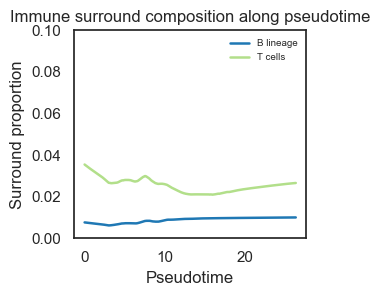

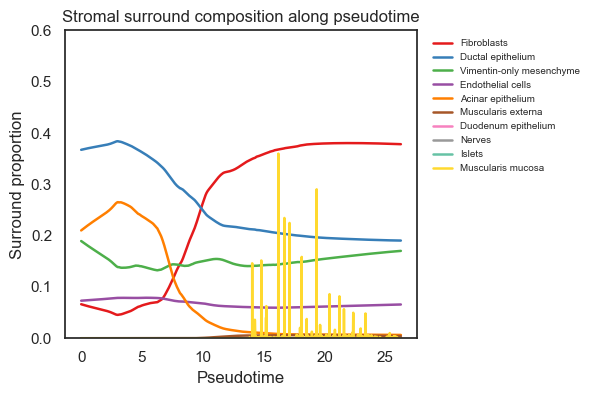

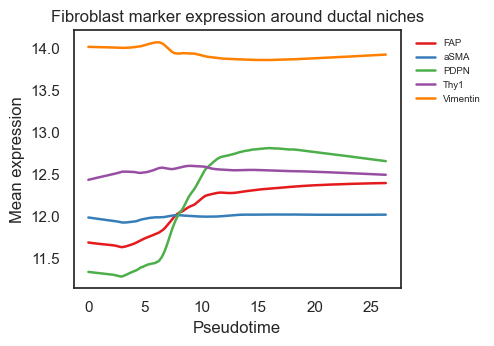

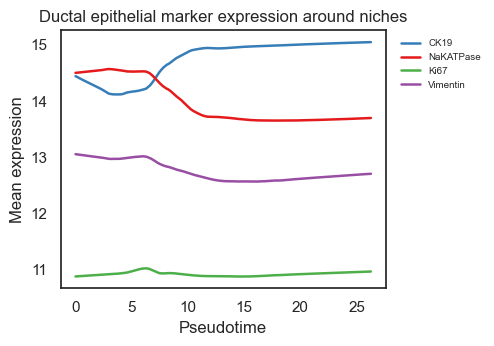

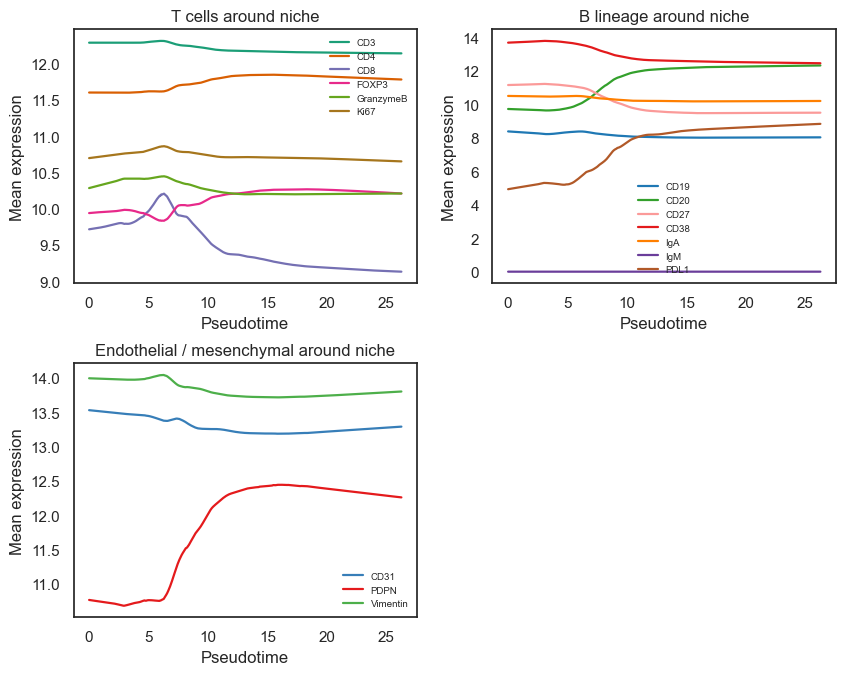

,feature,label,group
0,surround_prop__B_lineage,B lineage,immune proportions
1,surround_prop__T_cells,T cells,immune proportions
2,surround_prop__Fibroblasts,Fibroblasts,stromal proportions
3,surround_prop__pancreatic_ductal_epithelium,Ductal epithelium,stromal proportions
4,surround_prop__Vimentin_only_mesenchyme,Vimentin-only mesenchyme,stromal proportions
5,surround_prop__Endothelial_cells,Endothelial cells,stromal proportions
6,surround_prop__pancreatic_acinar_epithelium,Acinar epithelium,stromal proportions
7,surround_prop__Muscularis_externa,Muscularis externa,stromal proportions
8,surround_prop__Duodenum_epithelial,Duodenum epithelium,stromal proportions
9,surround_prop__Nerves,Nerves,stromal proportions


In [24]:
# Cell 3: plot configs + actual plots

immune_prop_map = {
    "surround_prop__B_lineage": ("B lineage", "#1f78b4"),
    "surround_prop__T_cells": ("T cells", "#b2df8a"),
}

stromal_prop_map = {
    "surround_prop__Fibroblasts": ("Fibroblasts", "#e41a1c"),
    "surround_prop__pancreatic_ductal_epithelium": ("Ductal epithelium", "#377eb8"),
    "surround_prop__Vimentin_only_mesenchyme": ("Vimentin-only mesenchyme", "#4daf4a"),
    "surround_prop__Endothelial_cells": ("Endothelial cells", "#984ea3"),
    "surround_prop__pancreatic_acinar_epithelium": ("Acinar epithelium", "#ff7f00"),
    "surround_prop__Muscularis_externa": ("Muscularis externa", "#a65628"),
    "surround_prop__Duodenum_epithelial": ("Duodenum epithelium", "#f781bf"),
    "surround_prop__Nerves": ("Nerves", "#999999"),
    "surround_prop__Islets": ("Islets", "#66c2a5"),
    "surround_prop__Muscularis_mucosa": ("Muscularis mucosa", "#ffd92f"),
}

fibro_marker_map = {
    surround_marker_col("Fibroblasts", "FAP_expr"): ("FAP", "#e41a1c"),
    surround_marker_col("Fibroblasts", "aSMA_expr"): ("aSMA", "#377eb8"),
    surround_marker_col("Fibroblasts", "PDPN_expr"): ("PDPN", "#4daf4a"),
    surround_marker_col("Fibroblasts", "Thy1_expr"): ("Thy1", "#984ea3"),
    surround_marker_col("Fibroblasts", "Vimentin_expr"): ("Vimentin", "#ff7f00"),
}

duct_marker_map = {
    surround_marker_col("pancreatic ductal epithelium", "CK19_expr"): ("CK19", "#377eb8"),
    surround_marker_col("pancreatic ductal epithelium", "NaKATPase_expr"): ("NaKATPase", "#e41a1c"),
    surround_marker_col("pancreatic ductal epithelium", "Ki67_expr"): ("Ki67", "#4daf4a"),
    surround_marker_col("pancreatic ductal epithelium", "Vimentin_expr"): ("Vimentin", "#984ea3"),
}

immune_marker_group_maps = {
    "T cells around niche": {
        surround_marker_col("T cells", "CD3_expr"): ("CD3", "#1b9e77"),
        surround_marker_col("T cells", "CD4_2_expr"): ("CD4", "#d95f02"),
        surround_marker_col("T cells", "CD8_2_expr"): ("CD8", "#7570b3"),
        surround_marker_col("T cells", "FOXP3_2_expr"): ("FOXP3", "#e7298a"),
        surround_marker_col("T cells", "GranzymeB_expr"): ("GranzymeB", "#66a61e"),
        surround_marker_col("T cells", "Ki67_expr"): ("Ki67", "#a6761d"),
    },
    "B lineage around niche": {
        surround_marker_col("B lineage", "CD19_expr"): ("CD19", "#1f78b4"),
        surround_marker_col("B lineage", "CD20_expr"): ("CD20", "#33a02c"),
        surround_marker_col("B lineage", "CD27_expr"): ("CD27", "#fb9a99"),
        surround_marker_col("B lineage", "CD38_expr"): ("CD38", "#e31a1c"),
        surround_marker_col("B lineage", "IgA_expr"): ("IgA", "#ff7f00"),
        surround_marker_col("B lineage", "IgM_expr"): ("IgM", "#6a3d9a"),
        surround_marker_col("B lineage", "PDL1_expr"): ("PDL1", "#b15928"),
    },
    "Endothelial / mesenchymal around niche": {
        surround_marker_col("Endothelial cells", "CD31_expr"): ("CD31", "#377eb8"),
        surround_marker_col("Endothelial cells", "PDPN_expr"): ("PDPN", "#e41a1c"),
        surround_marker_col("Vimentin only mesenchyme", "Vimentin_expr"): ("Vimentin", "#4daf4a"),
    },
}

immune_summary_df = plot_lowess_feature_map(
    surround_plot_df,
    immune_prop_map,
    title="Immune surround composition along pseudotime",
    ylabel="Surround proportion",
    ylim=(0, 0.1),
    figsize=(3.2, 3.0),
    legend_loc="upper right",
)

stromal_summary_df = plot_lowess_feature_map(
    surround_plot_df,
    stromal_prop_map,
    title="Stromal surround composition along pseudotime",
    ylabel="Surround proportion",
    ylim=(0, 0.6),
    figsize=(6.0, 4.0),
    legend_loc="upper left",
    legend_bbox=(1.02, 1.0),
)

fibro_marker_summary_df = plot_lowess_feature_map(
    surround_plot_df,
    fibro_marker_map,
    title="Fibroblast marker expression around ductal niches",
    ylabel="Mean expression",
    figsize=(5.0, 3.5),
    legend_loc="upper left",
    legend_bbox=(1.02, 1.0),
)

duct_marker_summary_df = plot_lowess_feature_map(
    surround_plot_df,
    duct_marker_map,
    title="Ductal epithelial marker expression around niches",
    ylabel="Mean expression",
    figsize=(5.0, 3.5),
    legend_loc="upper left",
    legend_bbox=(1.02, 1.0),
)

marker_panel_summary_df = plot_lowess_group_panels(
    surround_plot_df,
    immune_marker_group_maps,
    n_cols=2,
    figsize_scale=3.4,
    ylabel="Mean expression",
)

pd.concat(
    [
        immune_summary_df.assign(group="immune proportions"),
        stromal_summary_df.assign(group="stromal proportions"),
        fibro_marker_summary_df.assign(group="fibro markers"),
        duct_marker_summary_df.assign(group="duct markers"),
        marker_panel_summary_df,
    ],
    ignore_index=True,
)


In [25]:
niche_key = "pancreatic ductal epithelium_mask_component"

tier_b_labels = (
    adata.obs["Tier_B"]
    .value_counts()
    .loc[lambda s: ~s.index.isin(["noise", "Unknown"])]
    .index.tolist()
)

surround_context_df_B = se.summarize_niche_surrounding_context(
    adata,
    niche_key=niche_key,
    phenotype_key="Tier_B",
    phenotype_labels=tier_b_labels,
    surround_hops=5,
)

surround_plot_df_B = surround_context_df_B.merge(
    niche_result_pathology[[niche_key, "image_id", "elpigraph_pseudotime", "elpigraph_edge_id"]],
    on=[niche_key, "image_id"],
    how="left",
)

surround_plot_df_B.head()

,pancreatic ductal epithelium_mask_component,image_id,n_cells,n_surround,surround__hop_1__n_cells,surround__hop_2__n_cells,surround__hop_3__n_cells,surround__hop_4__n_cells,surround__hop_5__n_cells,surround_prop__pancreatic_ductal_epithelium,...,surround_prop__PDL1__B_cells,surround__PDL1__B_cells__n_cells,surround_prop__plasmablasts,surround__plasmablasts__n_cells,surround_prop__B_lineage,surround__B_lineage__n_cells,surround_prop__Tfh_like_cells,surround__Tfh_like_cells__n_cells,elpigraph_pseudotime,elpigraph_edge_id
0,global__component_0,34434_1,8.0,169.0,23.0,31.0,30.0,33.0,52.0,0.106509,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,22.569000,29.0
1,global__component_1,34434_1,104.0,1088.0,171.0,197.0,227.0,247.0,246.0,0.271140,...,0.001838,2.0,0.000000,0.0,0.003676,4.0,0.0,0.0,4.659995,40.0
2,global__component_10,34434_1,25.0,926.0,106.0,129.0,178.0,230.0,283.0,0.281857,...,0.001080,1.0,0.000000,0.0,0.001080,1.0,0.0,0.0,5.238981,22.0
3,global__component_100,34434_1,28.0,914.0,86.0,142.0,194.0,233.0,259.0,0.243982,...,0.001094,1.0,0.002188,2.0,0.000000,0.0,0.0,0.0,5.617821,13.0
4,global__component_1000,34434_1,10.0,827.0,39.0,95.0,160.0,246.0,287.0,0.437727,...,0.000000,0.0,0.001209,1.0,0.000000,0.0,0.0,0.0,4.204156,43.0


In [26]:
adata[adata.obs["Tier_A"]=="T cells"].obs["Tier_B"].value_counts()

Tier_B
activated CD4 T cells    36501
activated CD8 T cells    22150
CD8 T cells              17582
CD4 T cells              16697
Tregs                     5673
Th2-like cells            4389
cytotoxic CD8 T cells     3235
Tfh-like cells              64
Name: count, dtype: int64

In [27]:
adata[adata.obs["Tier_A"]=="B lineage"].obs["Tier_B"].value_counts()

Tier_B
plasmablasts-like    24232
memory B cells       13299
naive B cells        12949
GZMB+ B cells         6204
APC-like B cells      1969
PDL1+ B cells         1315
plasmablasts           450
B lineage              396
Name: count, dtype: int64

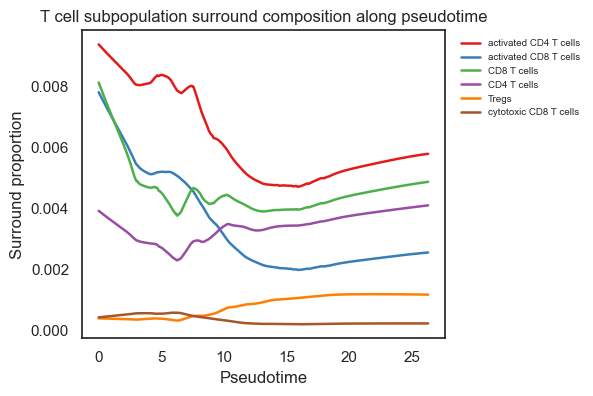

,feature,label
0,surround_prop__activated_CD4_T_cells,activated CD4 T cells
1,surround_prop__activated_CD8_T_cells,activated CD8 T cells
2,surround_prop__CD8_T_cells,CD8 T cells
3,surround_prop__CD4_T_cells,CD4 T cells
4,surround_prop__Tregs,Tregs
5,surround_prop__cytotoxic_CD8_T_cells,cytotoxic CD8 T cells


In [28]:
tier_b_prop_map = {
    "surround_prop__activated_CD4_T_cells": ("activated CD4 T cells", "#e41a1c"),
    "surround_prop__activated_CD8_T_cells": ("activated CD8 T cells", "#377eb8"),
    "surround_prop__CD8_T_cells": ("CD8 T cells", "#4daf4a"),
    "surround_prop__CD4_T_cells": ("CD4 T cells", "#984ea3"),
    "surround_prop__Tregs": ("Tregs", "#ff7f00"),
    "surround_prop__Th2-like_cells": ("Th2-like", "#ffff33"),
    "surround_prop__cytotoxic_CD8_T_cells": ("cytotoxic CD8 T cells", "#a65628"),
}

tier_b_prop_map = {
    k: v for k, v in tier_b_prop_map.items()
    if k in surround_plot_df_B.columns
}

plot_lowess_feature_map(
    surround_plot_df_B,
    tier_b_prop_map,
    title="T cell subpopulation surround composition along pseudotime",
    ylabel="Surround proportion",
    figsize=(6, 4),
    legend_loc="upper left",
    legend_bbox=(1.02, 1.0),
)


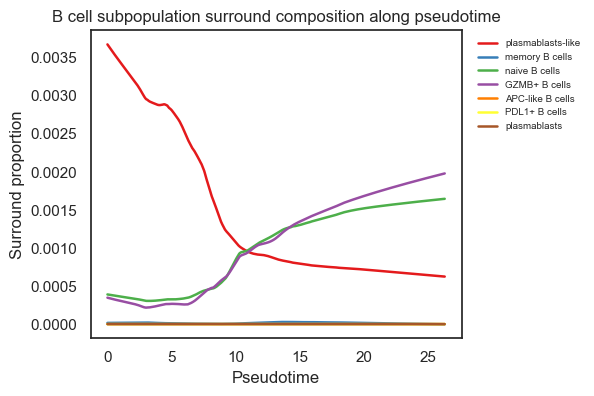

,feature,label
0,surround_prop__plasmablasts_like,plasmablasts-like
1,surround_prop__memory_B_cells,memory B cells
2,surround_prop__naive_B_cells,naive B cells
3,surround_prop__GZMB__B_cells,GZMB+ B cells
4,surround_prop__APC_like_B_cells,APC-like B cells
5,surround_prop__PDL1__B_cells,PDL1+ B cells
6,surround_prop__plasmablasts,plasmablasts


In [29]:
tier_b_prop_map = {
    "surround_prop__plasmablasts_like": ("plasmablasts-like", "#e41a1c"),
    "surround_prop__memory_B_cells": ("memory B cells", "#377eb8"),
    "surround_prop__naive_B_cells": ("naive B cells", "#4daf4a"),
    "surround_prop__GZMB__B_cells": ("GZMB+ B cells", "#984ea3"),
    "surround_prop__APC_like_B_cells": ("APC-like B cells", "#ff7f00"),
    "surround_prop__PDL1__B_cells": ("PDL1+ B cells", "#ffff33"),
    "surround_prop__plasmablasts": ("plasmablasts", "#a65628"),
}

tier_b_prop_map = {
    k: v for k, v in tier_b_prop_map.items()
    if k in surround_plot_df_B.columns
}

plot_lowess_feature_map(
    surround_plot_df_B,
    tier_b_prop_map,
    title="B cell subpopulation surround composition along pseudotime",
    ylabel="Surround proportion",
    figsize=(6, 4),
    legend_loc="upper left",
    legend_bbox=(1.02, 1.0),
)

In [40]:
interaction_cell_df = se.compute_epithelial_centered_interaction_dynamics(
    adata,
    pseudotime_key="elpigraph_pseudotime_pathology",
    phenotype_key="Tier_A",
    target_phenotypes=["Fibroblasts", "T cells", "B lineage"],
    source_phenotype="pancreatic ductal epithelium",
    radius_um=30,
    pixel_size_um=0.325,
    pseudotime_bin_count=10,
)

interaction_bin_df = se.summarize_epithelial_interaction_dynamics(
    interaction_cell_df,
    pseudotime_key="elpigraph_pseudotime_pathology",
)


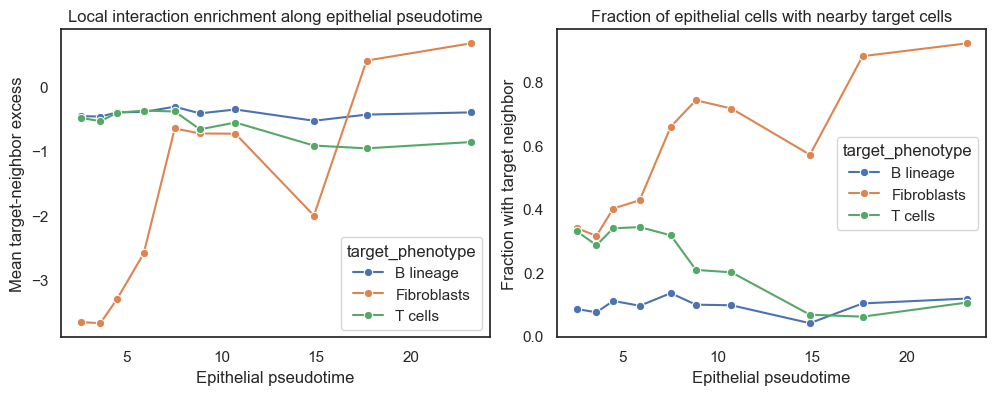

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

sns.lineplot(
    data=interaction_bin_df,
    x="pseudotime_median",
    y="mean_target_neighbor_excess",
    hue="target_phenotype",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Local interaction enrichment along epithelial pseudotime")
axes[0].set_xlabel("Epithelial pseudotime")
axes[0].set_ylabel("Mean target-neighbor excess")
axes[0].grid(False)

sns.lineplot(
    data=interaction_bin_df,
    x="pseudotime_median",
    y="fraction_source_with_target_neighbor",
    hue="target_phenotype",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Fraction of epithelial cells with nearby target cells")
axes[1].set_xlabel("Epithelial pseudotime")
axes[1].set_ylabel("Fraction with target neighbor")
axes[1].grid(False)

plt.tight_layout()
plt.show()


In [42]:
interaction_cell_df = se.compute_epithelial_centered_interaction_dynamics(
    adata,
    pseudotime_key="elpigraph_pseudotime_pathology",
    phenotype_key="Tier_B",
    target_phenotypes=["activated CD4 T cells", 
                       "activated CD8 T cells", 
                       "CD8 T cells", "CD4 T cells", 
                       "Tregs", "Th2-like cells", "cytotoxic CD8 T cells"],
    source_phenotype="pancreatic ductal epithelium",
    radius_um=30,
    pixel_size_um=0.325,
    pseudotime_bin_count=10,
)

interaction_bin_df = se.summarize_epithelial_interaction_dynamics(
    interaction_cell_df,
    pseudotime_key="elpigraph_pseudotime_pathology",
)

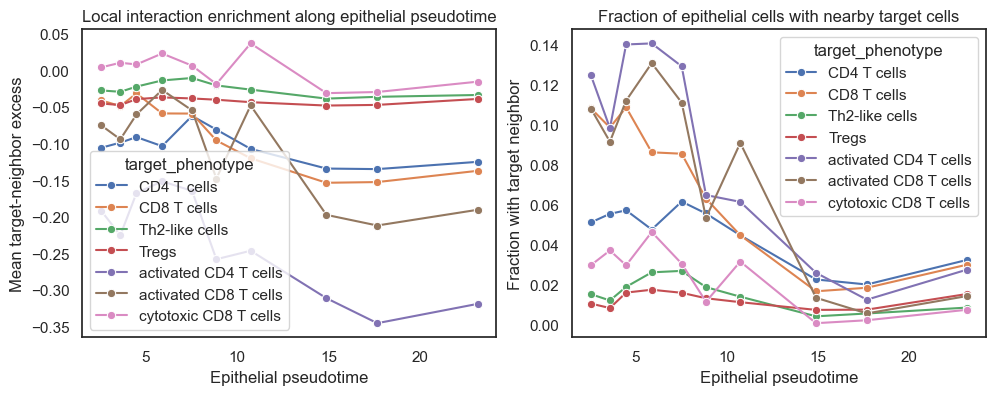

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

sns.lineplot(
    data=interaction_bin_df,
    x="pseudotime_median",
    y="mean_target_neighbor_excess",
    hue="target_phenotype",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Local interaction enrichment along epithelial pseudotime")
axes[0].set_xlabel("Epithelial pseudotime")
axes[0].set_ylabel("Mean target-neighbor excess")
axes[0].grid(False)

sns.lineplot(
    data=interaction_bin_df,
    x="pseudotime_median",
    y="fraction_source_with_target_neighbor",
    hue="target_phenotype",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Fraction of epithelial cells with nearby target cells")
axes[1].set_xlabel("Epithelial pseudotime")
axes[1].set_ylabel("Fraction with target neighbor")
axes[1].grid(False)

plt.tight_layout()
plt.show()


In [44]:
interaction_cell_df = se.compute_epithelial_centered_interaction_dynamics(
    adata,
    pseudotime_key="elpigraph_pseudotime_pathology",
    phenotype_key="Tier_B",
    target_phenotypes=["plasmablasts-like", "memory B cells", "naive B cells", "GZMB+ B cells", "APC-like B cells", "PDL1+ B cells", "plasmablasts"],
    source_phenotype="pancreatic ductal epithelium",
    radius_um=30,
    pixel_size_um=0.325,
    pseudotime_bin_count=10,
)

interaction_bin_df = se.summarize_epithelial_interaction_dynamics(
    interaction_cell_df,
    pseudotime_key="elpigraph_pseudotime_pathology",
)

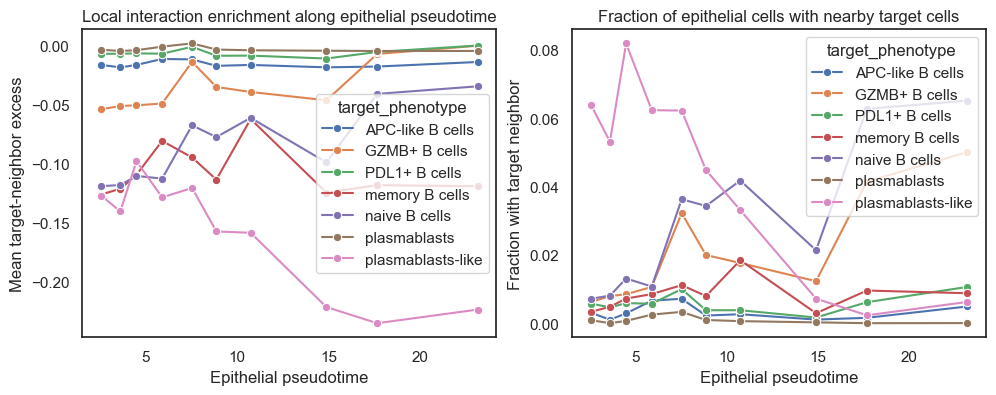

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

sns.lineplot(
    data=interaction_bin_df,
    x="pseudotime_median",
    y="mean_target_neighbor_excess",
    hue="target_phenotype",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Local interaction enrichment along epithelial pseudotime")
axes[0].set_xlabel("Epithelial pseudotime")
axes[0].set_ylabel("Mean target-neighbor excess")
axes[0].grid(False)

sns.lineplot(
    data=interaction_bin_df,
    x="pseudotime_median",
    y="fraction_source_with_target_neighbor",
    hue="target_phenotype",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Fraction of epithelial cells with nearby target cells")
axes[1].set_xlabel("Epithelial pseudotime")
axes[1].set_ylabel("Fraction with target neighbor")
axes[1].grid(False)

plt.tight_layout()
plt.show()
